## Задание

Постройте модель на основе полносвязных слоёв для классификации Fashion MNIST из библиотеки torchvision (datasets).
Получите качество на тестовой выборке не ниже 88%

Инструкция по выполнению задания

Скачайте тренировочную и тестовою часть датасета Fashion MNIST
Постройте модель, выбрав стартовую архитектуру
Обучите модель и сверьте качество на тестовой части с заданным порогом
Изменяйте архитектуру модели пока качество на тестовой части не будет выше порога. 
Вариации архитектуры можно реализовать через изменение количества слоёв, количества нейронов в слоях и использование регуляризации. 
Можно использовать различные оптимизаторы.

Кол-во изображений для тренировки 60000, для теста 10000
Кол-во классов тренировки 10, для теста 10
(28, 28)


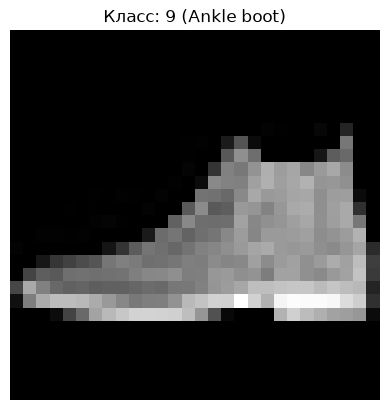

In [ ]:
import torch
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

# Загрузка тренировочного датасета
train_dataset = torchvision.datasets.FashionMNIST(
    root='./2.data',  # Корневой каталог для хранения данных
    train=True,    # True для обучающей выборки, False для тестовой
    download=True, # Если True, данные будут скачаны из интернета
    transform=ToTensor()  # Преобразование данных в тензоры
)

# Загрузка тестового датасета
test_dataset = torchvision.datasets.FashionMNIST(
    root='./2.data',  # Корневой каталог тот же
    train=False,    # False для тестовой
    download=True,
    transform=ToTensor()
)

print(f'Кол-во изображений для тренировки {len(train_dataset)}, для теста {len(test_dataset)}')
print(f'Кол-во классов тренировки {len(train_dataset.classes)}, для теста {len(test_dataset.classes)}')

# Полюбопытствуем че там вообще есть
image, label = test_dataset[0] # 0 - ботинок, 1 - кафтан, 2 - варенки и т.д.

# image — это тензор [1, 28, 28], label это число, скаляр
image_np.shape
image_np = image.squeeze().numpy() # убираем лишнюю размерность для imshow

plt.imshow(image_np, cmap='gray')
plt.title(f'Класс: {label} ({test_dataset.classes[label]})')
plt.axis('off')
plt.show()

## Загрузчики

In [6]:
BATCH_SIZE=256

train = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

## Модель №1

Модель полностью скопирована с "Занятия 2. Многослойная нейронная сеть". Показатели растут медленно, но какого-то плато за 10 эпох не ощущается, сначала прошел 10 эпох, потом выставил 100, сделал вывод что признаков переобучения нет. Чтобы узнать где плато, зарядил большое количество эпох.

Если выставить большое количество эпох, >500 то уже к 450-й эпохе требуемая 0.88 точность на тесте будет неуверенно, но достигнута и далее почти расти не будет.

Результаты: Эпоха 460, Трен. потери: 0.21341271476542695, Трен. точность: 0.9270166666666667, Тест потери: 0.32166153006255627, Тест точность: 0.8812

In [7]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 10)
)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
loss = torch.nn.CrossEntropyLoss()
trainer = torch.optim.SGD(model.parameters(), lr=.01)
num_epochs = 500

import time

def train_model():
    for ep in range(num_epochs):
        train_iters, train_passed  = 0, 0
        train_loss, train_acc = 0., 0.
        start=time.time()
        
        model.train()
        for X, y in train:
            trainer.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            trainer.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)
        
        test_iters, test_passed  = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        for X, y in test:
            y_pred = model(X)
            l = loss(y_pred, y)
            test_loss += l.item()
            test_acc += (y_pred.argmax(dim=1) == y).sum().item()
            test_iters += 1
            test_passed += len(X)
            
        print("Эпоха: {}, заняло: {:.3f}, Трен. потери: {}, Трен. точность: {}, Тест потери: {}, Тест точность: {}".format(
            ep, time.time() - start, train_loss / train_iters, train_acc / train_passed,
            test_loss / test_iters, test_acc / test_passed)
        )

In [14]:
train_model()

Эпоха: 0, заняло: 3.230, Трен. потери: 0.3499263866784725, Трен. точность: 0.8786833333333334, Тест потери: 0.395019655674696, Тест точность: 0.8619
Эпоха: 1, заняло: 4.891, Трен. потери: 0.3491585952170352, Трен. точность: 0.8786333333333334, Тест потери: 0.39788218811154363, Тест точность: 0.8598
Эпоха: 2, заняло: 6.745, Трен. потери: 0.3487299514577744, Трен. точность: 0.8791166666666667, Тест потери: 0.40540526807308197, Тест точность: 0.8593
Эпоха: 3, заняло: 3.490, Трен. потери: 0.3476314721589393, Трен. точность: 0.8796333333333334, Тест потери: 0.3929414801299572, Тест точность: 0.8635
Эпоха: 4, заняло: 3.230, Трен. потери: 0.3475738988911852, Трен. точность: 0.8793666666666666, Тест потери: 0.396561548858881, Тест точность: 0.8609
Эпоха: 5, заняло: 5.823, Трен. потери: 0.34637249670130144, Трен. точность: 0.8796166666666667, Тест потери: 0.38732554093003274, Тест точность: 0.8618
Эпоха: 6, заняло: 3.980, Трен. потери: 0.3459098983318248, Трен. точность: 0.8800666666666667, Тес